# Give Me Some Credit

## Import libraries, functions and data

First, we import and study the dataset using some specific plots. We also clean it by handling missing values and suspicious data.

In [3]:
import pandas as pd
import seaborn as sns
import numpy as np

import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

import jax
import jax.numpy as jnp

# from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import roc_curve, roc_auc_score, accuracy_score, confusion_matrix, classification_report
from sklearn.linear_model import LogisticRegression

from xgboost import XGBClassifier
import lightgbm as lgb
from catboost import CatBoostClassifier

In [ ]:
def plot_roc_curve(fpr, tpr, label="ROC Curve"):
    """
    Plots the Receiver Operating Characteristic (ROC) curve.
    Args:
        fpr: False Positive Rate
        tpr: True Positive Rate
        label: Label for the plot legend
    """
    plt.figure(figsize=(6, 6))

    plt.plot(fpr, tpr, label=label)
    plt.plot([0, 1], [0, 1], color='red', linestyle='--')

    plt.axis([0, 1, 0, 1])
    plt.xlabel("False Positive Rate (1 - SPECIFICITY)")
    plt.ylabel("True Positive Rate (SENSITIVITY)")
    plt.title(label)

    plt.grid(True, linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

In [5]:
train_df = pd.read_csv("../data/cs-training.csv")
test_df = pd.read_csv("../data/cs-test.csv")

## Exploratory data analysis

In [6]:
train_df.head()

,Unnamed: 0,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
0,1,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
1,2,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
2,3,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
3,4,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
4,5,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0


In [7]:
test_df.head()

,Unnamed: 0,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
0,1,NaN,0.885519,43,0,0.177513,5700.0,4,0,0,0,0.0
1,2,NaN,0.463295,57,0,0.527237,9141.0,15,0,4,0,2.0
2,3,NaN,0.043275,59,0,0.687648,5083.0,12,0,1,0,2.0
3,4,NaN,0.280308,38,1,0.925961,3200.0,7,0,2,0,0.0
4,5,NaN,1.000000,27,0,0.019917,3865.0,4,0,0,0,1.0


In [ ]:
# Rename the 'Unnamed: 0' column to 'ID' for both train and test datasets, this column likely represents a unique identifier for each record.
train_df.rename(columns={'Unnamed: 0':'ID'}, inplace=True)
test_df.rename(columns={'Unnamed: 0':'ID'}, inplace=True)

In [9]:
train_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 12 columns):
 #   Column                                Non-Null Count   Dtype  
---  ------                                --------------   -----  
 0   ID                                    150000 non-null  int64  
 1   SeriousDlqin2yrs                      150000 non-null  int64  
 2   RevolvingUtilizationOfUnsecuredLines  150000 non-null  float64
 3   age                                   150000 non-null  int64  
 4   NumberOfTime30-59DaysPastDueNotWorse  150000 non-null  int64  
 5   DebtRatio                             150000 non-null  float64
 6   MonthlyIncome                         120269 non-null  float64
 7   NumberOfOpenCreditLinesAndLoans       150000 non-null  int64  
 8   NumberOfTimes90DaysLate               150000 non-null  int64  
 9   NumberRealEstateLoansOrLines          150000 non-null  int64  
 10  NumberOfTime60-89DaysPastDueNotWorse  150000 non-null  int64  
 11  NumberOfDep

In [10]:
test_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 101503 entries, 0 to 101502
Data columns (total 12 columns):
 #   Column                                Non-Null Count   Dtype  
---  ------                                --------------   -----  
 0   ID                                    101503 non-null  int64  
 1   SeriousDlqin2yrs                      0 non-null       float64
 2   RevolvingUtilizationOfUnsecuredLines  101503 non-null  float64
 3   age                                   101503 non-null  int64  
 4   NumberOfTime30-59DaysPastDueNotWorse  101503 non-null  int64  
 5   DebtRatio                             101503 non-null  float64
 6   MonthlyIncome                         81400 non-null   float64
 7   NumberOfOpenCreditLinesAndLoans       101503 non-null  int64  
 8   NumberOfTimes90DaysLate               101503 non-null  int64  
 9   NumberRealEstateLoansOrLines          101503 non-null  int64  
 10  NumberOfTime60-89DaysPastDueNotWorse  101503 non-null  int64  
 11  NumberOfDep

In [11]:
train_df.describe().round(decimals=2)

,ID,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
count,150000.00,150000.00,150000.00,150000.00,150000.00,150000.00,120269.00,150000.00,150000.00,150000.00,150000.00,146076.00
mean,75000.50,0.07,6.05,52.30,0.42,353.01,6670.22,8.45,0.27,1.02,0.24,0.76
std,43301.41,0.25,249.76,14.77,4.19,2037.82,14384.67,5.15,4.17,1.13,4.16,1.12
min,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,37500.75,0.00,0.03,41.00,0.00,0.18,3400.00,5.00,0.00,0.00,0.00,0.00
50%,75000.50,0.00,0.15,52.00,0.00,0.37,5400.00,8.00,0.00,1.00,0.00,0.00
75%,112500.25,0.00,0.56,63.00,0.00,0.87,8249.00,11.00,0.00,2.00,0.00,1.00
max,150000.00,1.00,50708.00,109.00,98.00,329664.00,3008750.00,58.00,98.00,54.00,98.00,20.00


In [12]:
test_df.describe().round(decimals=2)

,ID,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
count,101503.00,0.0,101503.00,101503.00,101503.00,101503.00,81400.00,101503.00,101503.00,101503.00,101503.00,98877.00
mean,50752.00,NaN,5.31,52.41,0.45,344.48,6855.04,8.45,0.30,1.01,0.27,0.77
std,29301.54,NaN,196.16,14.78,4.54,1632.60,36508.60,5.14,4.52,1.11,4.50,1.14
min,1.00,NaN,0.00,21.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,25376.50,NaN,0.03,41.00,0.00,0.17,3408.00,5.00,0.00,0.00,0.00,0.00
50%,50752.00,NaN,0.15,52.00,0.00,0.36,5400.00,8.00,0.00,1.00,0.00,0.00
75%,76127.50,NaN,0.56,63.00,0.00,0.85,8200.00,11.00,0.00,2.00,0.00,1.00
max,101503.00,NaN,21821.00,104.00,98.00,268326.00,7727000.00,85.00,98.00,37.00,98.00,43.00


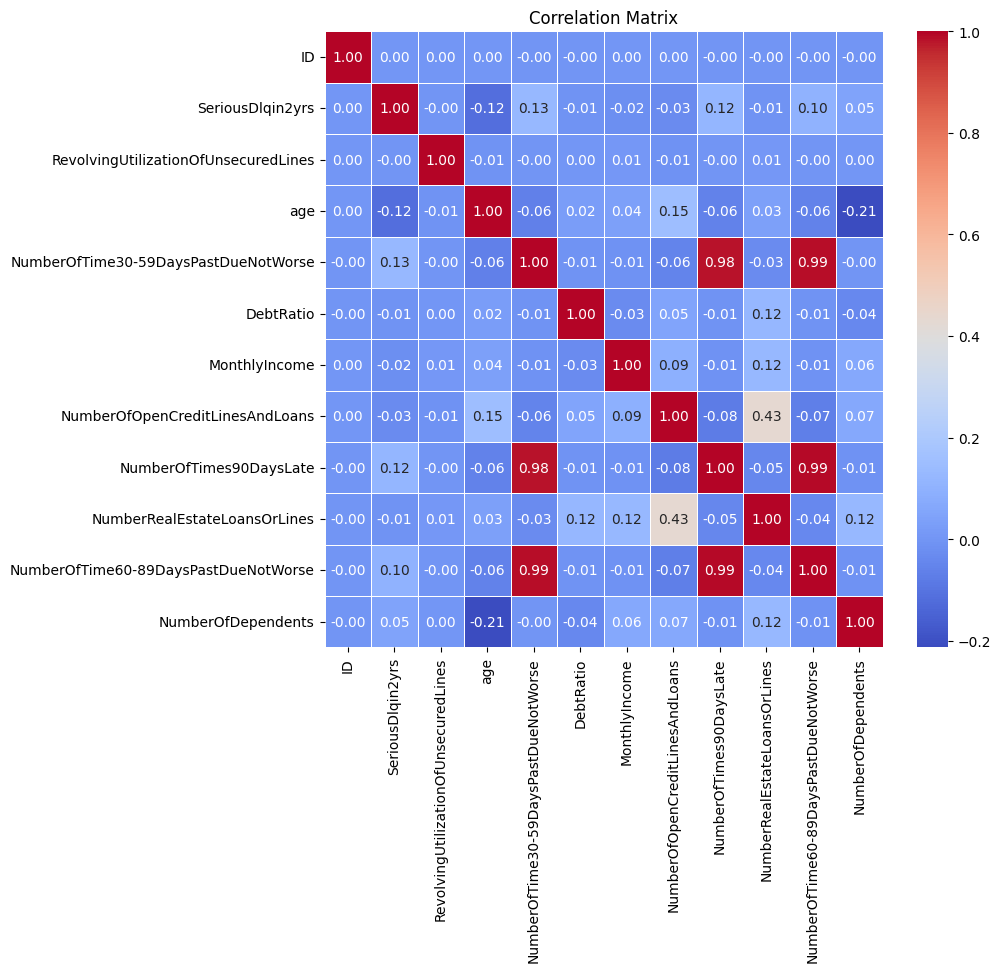

In [ ]:
#the correlation matrix of the training dataset to understand the relationships between the features and the target variable and with each other.
#in this case, we can see that there are some weird correlations between the features themselves, such as between 'RevolvingUtilizationOfUnsecuredLines' and 'DebtRatio', 
# which may indicate that these features are related to each other in some way, we investigate this further to understand the underlying reasons for this correlation. 

corr = train_df.corr()
fig = plt.figure(figsize=(9,8))
plt.title('Correlation Matrix')
ax = sns.heatmap(corr, annot=True, fmt='.2f', cmap="coolwarm", linewidths=0.5)
plt.show()

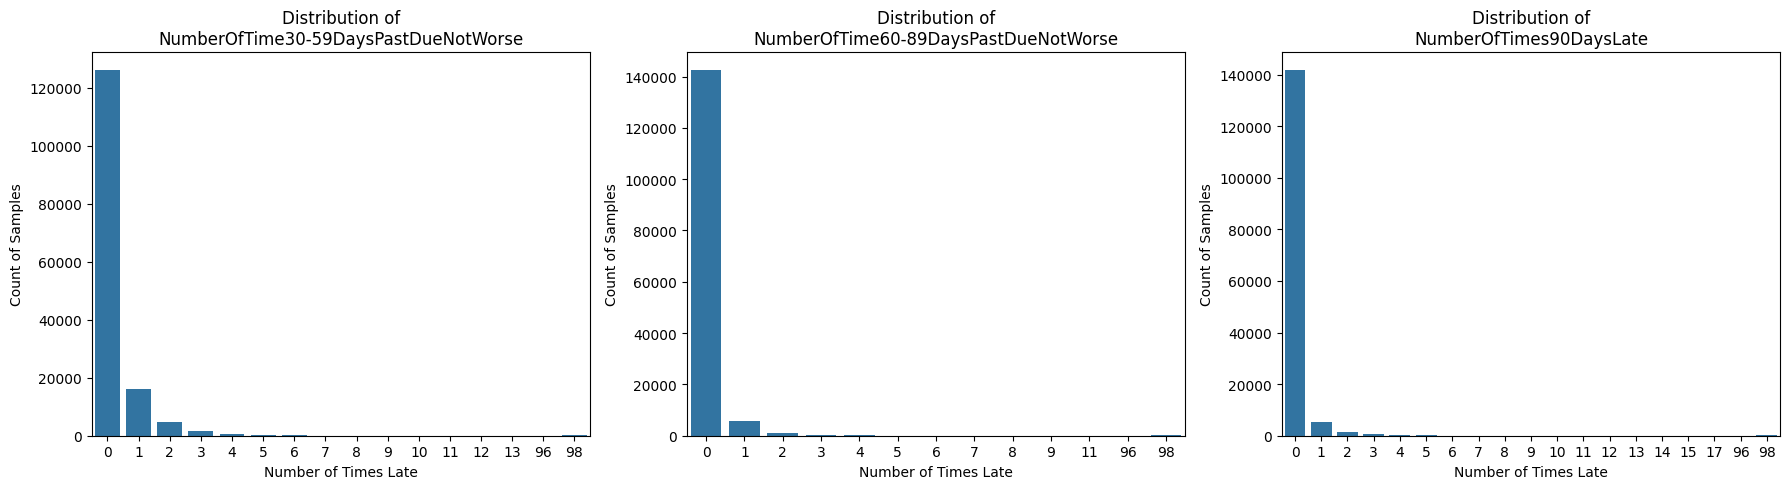

In [14]:
late_cols = [
    'NumberOfTime30-59DaysPastDueNotWorse',
    'NumberOfTime60-89DaysPastDueNotWorse',
    'NumberOfTimes90DaysLate'
]
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for i, col in enumerate(late_cols):
    sns.countplot(
        data=train_df,
        x=col,
        ax=axes[i]
    )
    axes[i].set_title(f'Distribution of\n{col}')
    axes[i].set_xlabel('Number of Times Late')
    axes[i].set_ylabel('Count of Samples')
plt.tight_layout()
plt.show()

In [15]:
count_age_zero = (train_df['age'] == 0).sum()
print(f"Number of samples with age = 0: {count_age_zero}")

Number of samples with age = 0: 1


In [16]:
wrong_mask = (train_df[late_cols[0]].isin([96, 98])) | \
             (train_df[late_cols[1]].isin([96, 98])) | \
             (train_df[late_cols[2]].isin([96, 98]))
wrong_samples = train_df[wrong_mask]

combinations_table = wrong_samples[late_cols].value_counts().reset_index(name='Count')
# wrong_samples[late_cols]: filtered dataset with corrupted rows only
# .value_counts(): it looks for rows that has the same three numbers and counts how many times that combination appears
# .reset_index(name='Count'): it flattens the .value_counts() output into a standard dataframe

print("There are " + str(len(wrong_samples)) + " corrupted samples:")
combinations_table.style.hide(axis="index")

There are 269 corrupted samples:


NumberOfTime30-59DaysPastDueNotWorse,NumberOfTime60-89DaysPastDueNotWorse,NumberOfTimes90DaysLate,Count
98,98,98,264
96,96,96,5


In [17]:
print(train_df.duplicated().value_counts())
print(test_df.duplicated().value_counts())
# no duplicated rows (all False)

False    150000
Name: count, dtype: int64
False    101503
Name: count, dtype: int64


In [18]:
mis_val = train_df.isnull().sum()
mis_val_percent = 100 * train_df.isnull().sum() / len(train_df)
mis_val_table = pd.concat([mis_val, mis_val_percent], axis=1)
mis_val_table_ren_columns = mis_val_table.rename(
columns = {0 : 'Missing Values', 1 : '% of Total Values'})
mis_val_table_ren_columns = mis_val_table_ren_columns[
    mis_val_table_ren_columns.iloc[:,1] != 0].sort_values(
'% of Total Values', ascending=False).round(1)
print ("There are " + str(mis_val_table_ren_columns.shape[0]) +
      " columns that have missing values:")
mis_val_table_ren_columns

There are 2 columns that have missing values:


,Missing Values,% of Total Values
MonthlyIncome,29731,19.8
NumberOfDependents,3924,2.6


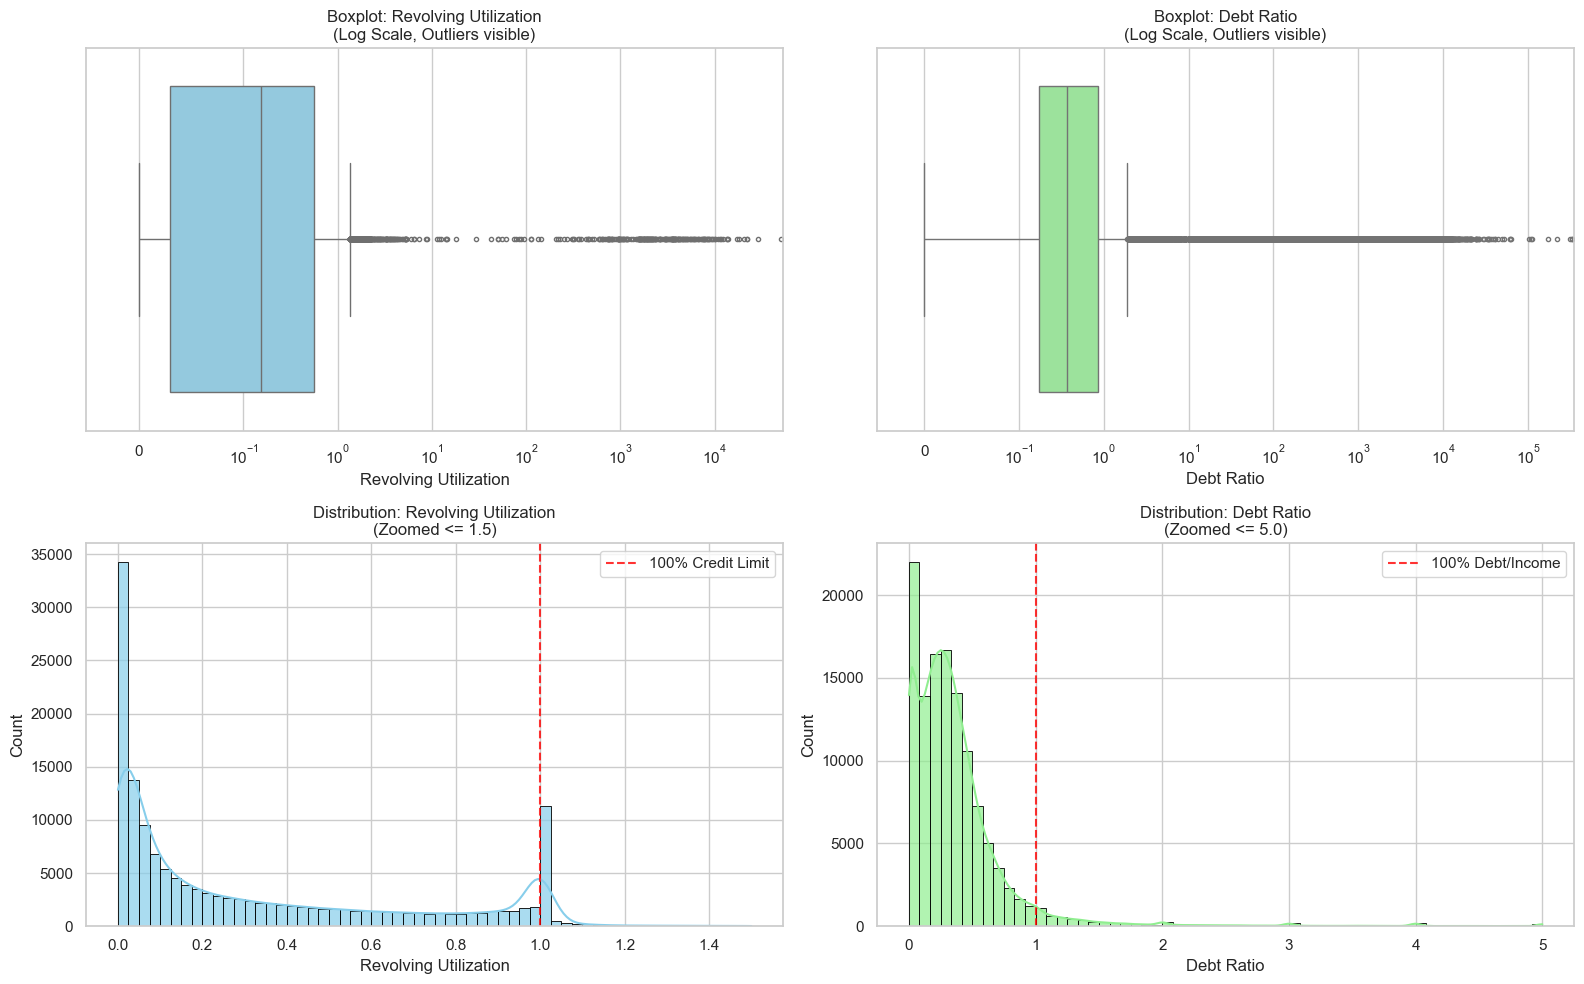

In [ ]:
#plotting the distribution of the two features with log scale and outliers visible, and zoomed histograms to show the main distribution without outliers
sns.set_theme(style="whitegrid")

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

sns.boxplot(x=train_df['RevolvingUtilizationOfUnsecuredLines'], ax=axes[0, 0], color='skyblue', fliersize=3)
axes[0, 0].set_title('Boxplot: Revolving Utilization\n(Log Scale, Outliers visible)', fontsize=12)
axes[0, 0].set_xlabel('Revolving Utilization')
axes[0, 0].set_xscale('symlog', linthresh=0.1)
axes[0, 0].set_xlim(left=-0.05) 
sns.boxplot(x=train_df['DebtRatio'], ax=axes[0, 1], color='lightgreen', fliersize=3)
axes[0, 1].set_title('Boxplot: Debt Ratio\n(Log Scale, Outliers visible)', fontsize=12)
axes[0, 1].set_xlabel('Debt Ratio')
axes[0, 1].set_xscale('symlog', linthresh=0.1)
axes[0, 1].set_xlim(left=-0.05) 



zoom_revolving = train_df[train_df['RevolvingUtilizationOfUnsecuredLines'] <= 1.5]['RevolvingUtilizationOfUnsecuredLines']
sns.histplot(zoom_revolving, bins=60, ax=axes[1, 0], color='skyblue', kde=True, edgecolor='black', alpha=0.7)
axes[1, 0].axvline(x=1.0, color='red', linestyle='--', linewidth=1.5, alpha=0.8, label='100% Credit Limit')
axes[1, 0].set_title('Distribution: Revolving Utilization\n(Zoomed <= 1.5)', fontsize=12)
axes[1, 0].set_xlabel('Revolving Utilization')
axes[1, 0].set_ylabel('Count')
axes[1, 0].legend()

zoom_debt = train_df[train_df['DebtRatio'] <= 5.0]['DebtRatio']
sns.histplot(zoom_debt, bins=60, ax=axes[1, 1], color='lightgreen', kde=True, edgecolor='black', alpha=0.7)
axes[1, 1].axvline(x=1.0, color='red', linestyle='--', linewidth=1.5, alpha=0.8, label='100% Debt/Income')
axes[1, 1].set_title('Distribution: Debt Ratio\n(Zoomed <= 5.0)', fontsize=12)
axes[1, 1].set_xlabel('Debt Ratio')
axes[1, 1].set_ylabel('Count')
axes[1, 1].legend()

plt.tight_layout()
plt.show()


In [16]:
wrong_revolving = (train_df['RevolvingUtilizationOfUnsecuredLines'] > 2.0).sum()
print(f"Samples with RevolvingUtilization > 2.0: {wrong_revolving}")
print(f"99% of RevolvingUtilization: {train_df['RevolvingUtilizationOfUnsecuredLines'].quantile(0.99)}")

Samples with RevolvingUtilization > 2.0: 371
99% of RevolvingUtilization: 1.0929557681400022


In [17]:
wrong_debt = (train_df['DebtRatio'] > 10.0).sum()
print(f"Samples with DebtRatio > 10.0: {wrong_debt}")
print(f"99% of DebtRatio: {train_df['DebtRatio'].quantile(0.99)}")

Samples with DebtRatio > 10.0: 28877
99% of DebtRatio: 4979.040000000037


## Imputing and cleaning

We fix *MonthlyIncome* and *NumberOfDependents*

In [18]:
inc_median = train_df['MonthlyIncome'].median()
dep_median = train_df['NumberOfDependents'].median()

inc_na_mask = train_df['MonthlyIncome'].isna()

train_df['MonthlyIncome'] = train_df['MonthlyIncome'].fillna(inc_median)
train_df['NumberOfDependents'] = train_df['NumberOfDependents'].fillna(dep_median).astype(int)

We fix *age*, *RevolvingUtilizationOfUnsecuredLines*, *DebtRatio*

In [19]:
train_df = train_df[train_df['age'] > 0]
train_df = train_df[train_df['RevolvingUtilizationOfUnsecuredLines'] <= 2.0]

train_df.loc[inc_na_mask, 'DebtRatio'] = train_df.loc[inc_na_mask, 'DebtRatio'] / inc_median
print(f"Samples with DebtRatio > 10.0 after MonthlyIncome imputation: {(train_df['DebtRatio'] > 10.0).sum()}")
train_df = train_df[train_df['DebtRatio'] <= 10.0]

Samples with DebtRatio > 10.0 after MonthlyIncome imputation: 2109


We fix *NumberOfTime30-59DaysPastDueNotWorse*, *NumberOfTime60-89DaysPastDueNotWorse* and *NumberOfTimes90DaysLate*

In [20]:
for col in late_cols:
    train_df = train_df[~train_df[col].isin([96, 98])]

In [21]:
print(f"New number of training samples: {len(train_df)}")

New number of training samples: 147250


## More data analysis

In [22]:
train_df.describe().round(decimals=2)

,ID,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
count,147250.00,147250.00,147250.00,147250.00,147250.00,147250.00,147250.00,147250.00,147250.00,147250.00,147250.00,147250.00
mean,75011.80,0.07,0.32,52.38,0.25,0.36,6511.08,8.48,0.09,1.02,0.06,0.74
std,43301.59,0.25,0.35,14.75,0.70,0.46,12983.54,5.14,0.48,1.13,0.33,1.11
min,1.00,0.00,0.00,21.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,37516.25,0.00,0.03,41.00,0.00,0.12,4000.00,5.00,0.00,0.00,0.00,0.00
50%,75025.50,0.00,0.15,52.00,0.00,0.28,5400.00,8.00,0.00,1.00,0.00,0.00
75%,112521.75,0.00,0.55,63.00,0.00,0.47,7467.00,11.00,0.00,2.00,0.00,1.00
max,150000.00,1.00,2.00,109.00,13.00,10.00,3008750.00,58.00,17.00,54.00,11.00,20.00


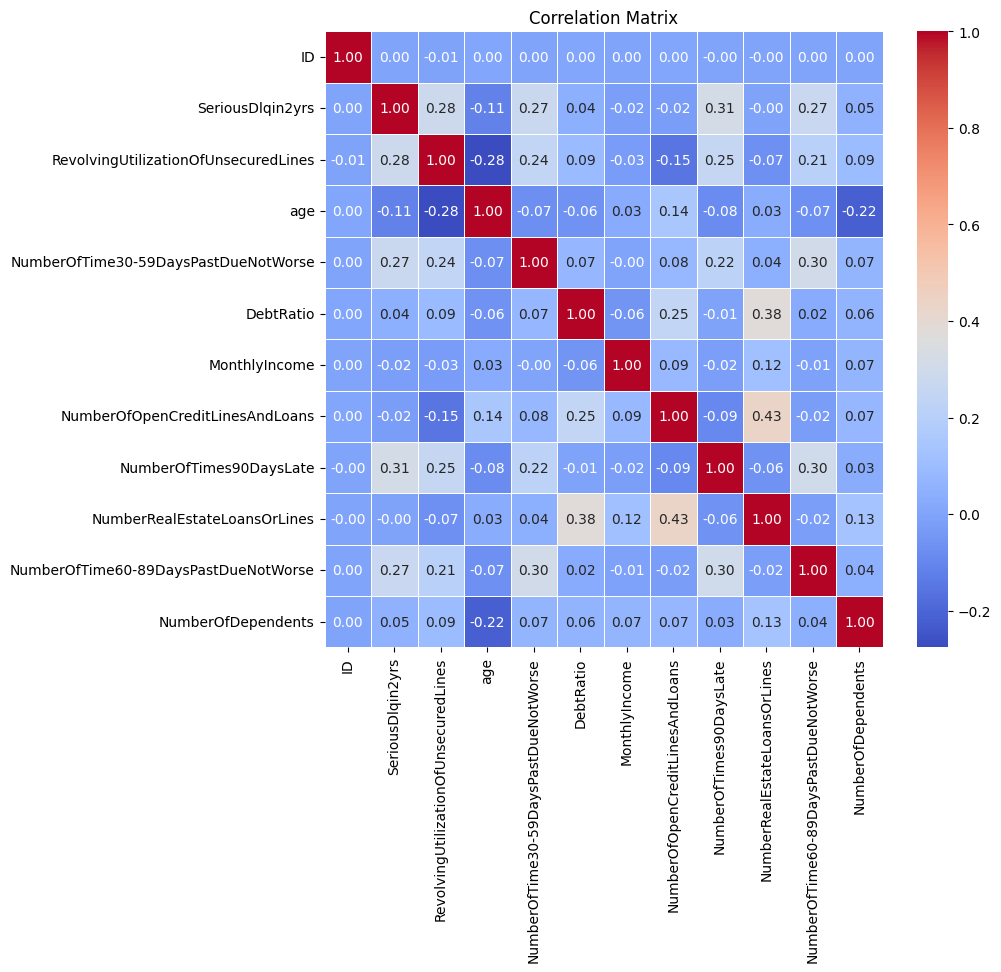

In [ ]:
# After cleaning the data, we can see that the correlation between 'RevolvingUtilizationOfUnsecuredLines' and 'DebtRatio' has decreased significantly, which suggests that the outliers and missing values were contributing to the strong correlation between these two features.
corr = train_df.corr()
fig = plt.figure(figsize=(9,8))
plt.title('Correlation Matrix')
ax = sns.heatmap(corr, annot=True, fmt='.2f', cmap="coolwarm", linewidths=0.5)
plt.show()

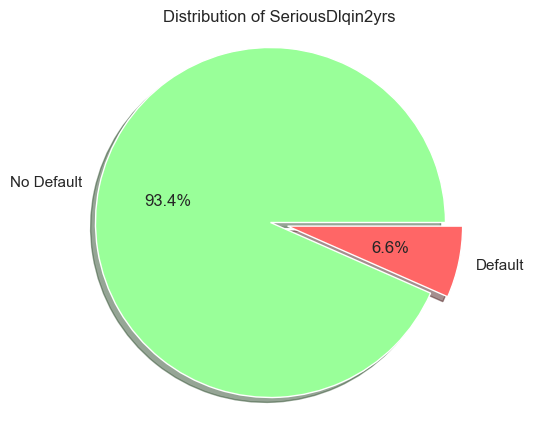

In [ ]:
#target distribution pie chart. the dataset is imbalanced, with a majority of samples not defaulting (SeriousDlqin2yrs = 0) and a smaller portion defaulting (SeriousDlqin2yrs = 1). 
# This imbalance can affect model performance, so we may need to consider techniques to address it during modeling.
target_counts = train_df['SeriousDlqin2yrs'].value_counts()

plt.figure(figsize=(5, 5))
plt.pie(
    target_counts,
    labels=['No Default', 'Default'],
    autopct='%1.1f%%', # it automatically computes percentages
    colors=['#99ff99', '#ff6666'],
    explode=(0, 0.1), # highlight the Default slice
    shadow=True
)
plt.title('Distribution of SeriousDlqin2yrs')
plt.axis('equal')
plt.show()

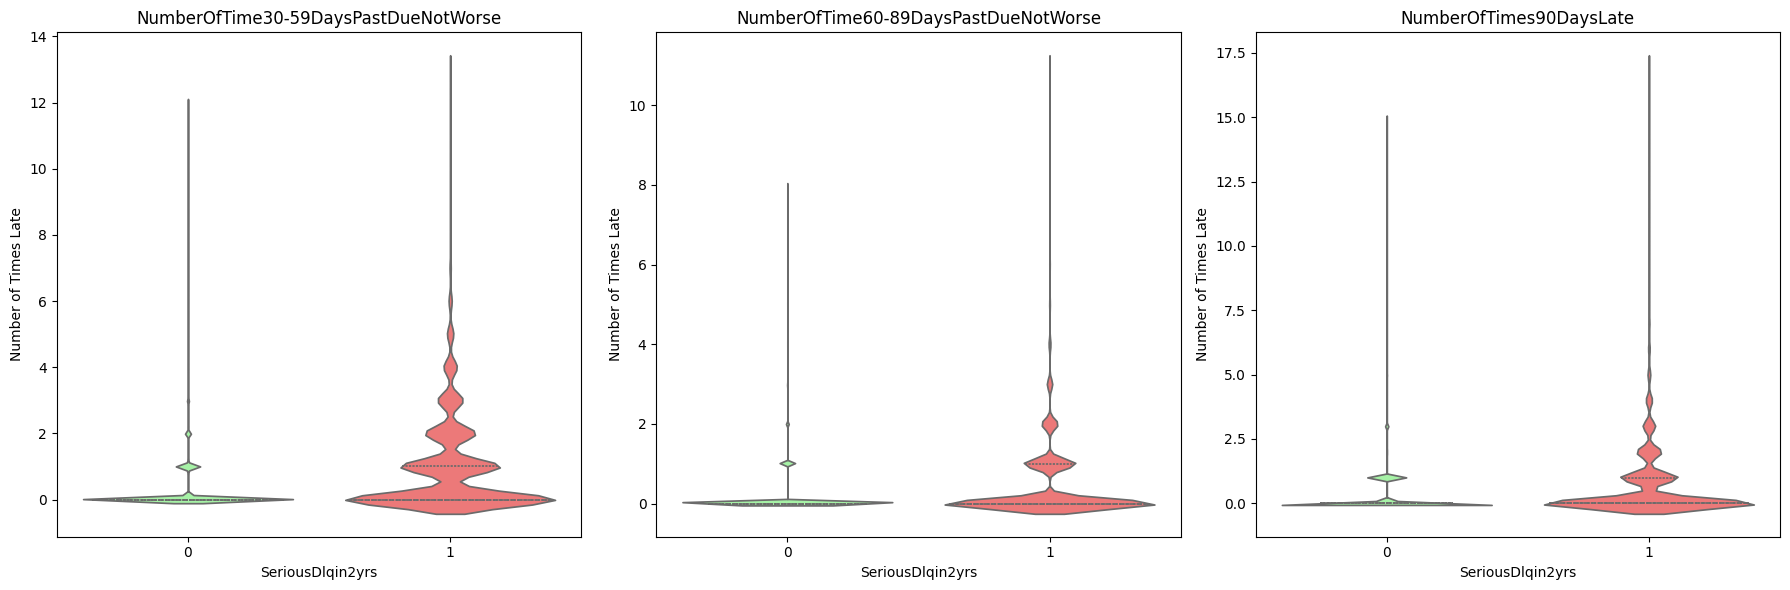

In [ ]:
#violin plots for the three late payment features, showing how their distributions differ between those who defaulted and those who did not.
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for i, feature in enumerate(late_cols):
    sns.violinplot(
        data=train_df,
        x='SeriousDlqin2yrs',
        y=feature,
        ax=axes[i],
        hue='SeriousDlqin2yrs',
        palette=['#99ff99', '#ff6666'],
        inner='quartile',
        legend=False
    )
    axes[i].set_title(feature)
    axes[i].set_xlabel('SeriousDlqin2yrs')
    axes[i].set_ylabel('Number of Times Late')
plt.tight_layout()
plt.show()

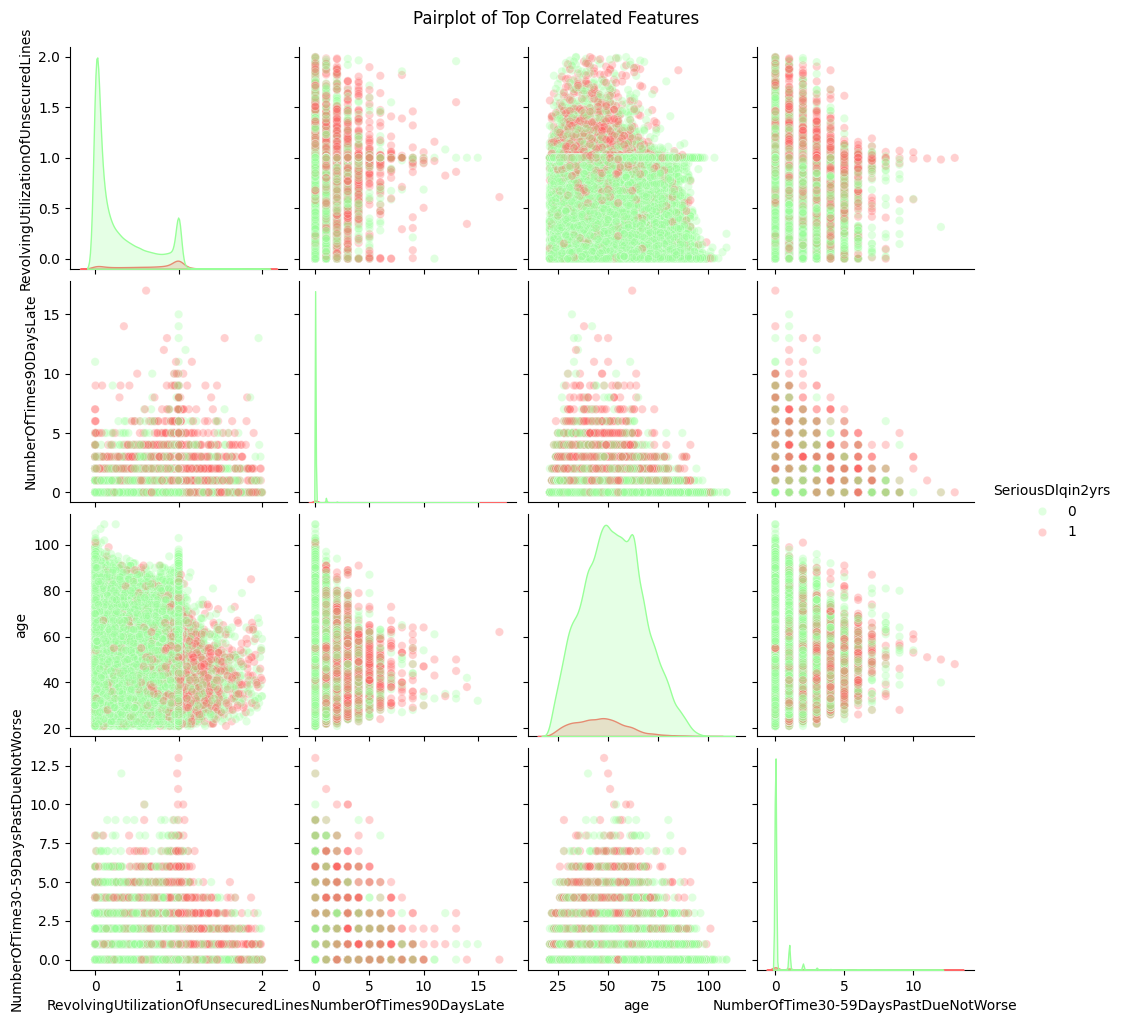

In [ ]:
# Pairplot of the top 4 features most correlated with serious delinquency (SeriousDlqin2yrs).
# Diagonal shows individual distributions; off-diagonal shows pairwise scatter plots.
# Red (class 1) clusters at higher values of late-payment features, confirming their
# predictive value. The age feature shows a more uniform distribution, but defaults are more common among younger individuals.

pairplot_cols = [
    'RevolvingUtilizationOfUnsecuredLines',
    'NumberOfTimes90DaysLate',
    'age',
    'NumberOfTime30-59DaysPastDueNotWorse',
    'SeriousDlqin2yrs'
]

sns.pairplot(
    train_df[pairplot_cols],
    hue='SeriousDlqin2yrs',
    palette=['#99ff99', '#ff6666'],
    plot_kws={'alpha': 0.3},
    diag_kind='kde'
)

plt.suptitle('Pairplot of Top Correlated Features', y=1.02)
plt.show()

## Models

After performing the necessary cleaning of the dataset, we start implementing our models, from the most basic ones like the logistic regression, building up to the Ensemble method.

In [35]:
X = train_df.drop(['SeriousDlqin2yrs', 'ID'], axis=1)
y = train_df['SeriousDlqin2yrs']

# W = test_df.drop(['SeriousDlqin2yrs', 'ID'], axis=1)
# z = test_df['SeriousDlqin2yrs'] # test_df doesn't have the target column, so we can't really use it.

In [ ]:
# We split the data into training and testing sets, using stratification to maintain the same class distribution in both sets.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=123, stratify=y
)

train_mean = X_train.mean(axis=0)
train_std = X_train.std(axis=0)

X_train_scaled = (X_train - train_mean) / train_std
X_test_scaled = (X_test - train_mean) / train_std

## Logistic Regression

In [37]:
X_train_array = np.array(X_train_scaled)
y_train_array = np.array(y_train)
X_test_array = np.array(X_test_scaled)
y_test_array = np.array(y_test)

In [38]:
#Since we already imputed the missing values with the median, there shouldn't be any NANs left. This is just a safety measure in case we missed something.
imputer = SimpleImputer(strategy='mean')
X_train_array_lr = imputer.fit_transform(X_train_scaled)
X_test_array_lr = imputer.transform(X_test_scaled)

model = LogisticRegression(max_iter=1000, class_weight='balanced')
model.fit(X_train_array_lr, y_train_array)




,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :ter

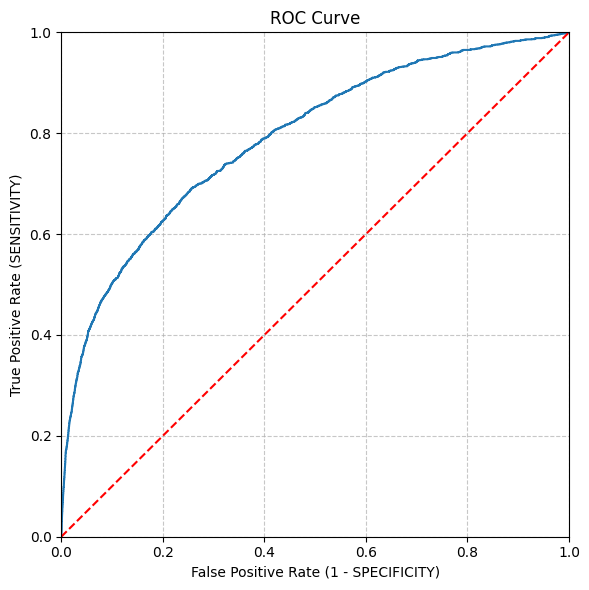

AUC Score: 0.7895156019577776
Threshold: 0.477, Sensitivity: 0.700
Specificity: 0.7274
Flagged as risky: 30.1% of all customers
TP: 1404, FP: 7632, TN: 20363, FN: 601
Total flagged: 9036
Actual defaults in test set: 2005


In [39]:
# predict probabilities on test set
lr_scores_proba = model.predict_proba(X_test_array_lr)
lr_preds = lr_scores_proba[:, 1]

lr_fpr, lr_tpr, thresholds = roc_curve(y_test, lr_preds)
plot_roc_curve(lr_fpr, lr_tpr)
print('AUC Score:', roc_auc_score(y_test, lr_preds))

# Find threshold that gives sensitivity >= 0.7
best_thresh = None
for thresh, sens in zip(thresholds, lr_tpr):
    if sens >= 0.70:
        best_thresh = thresh
        print(f"Threshold: {thresh:.3f}, Sensitivity: {sens:.3f}")
        break

# Apply threshold
y_pred = (lr_preds >= best_thresh).astype(int)

tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
specificity = tn / (tn + fp)

print(f"Specificity: {specificity:.4f}")
print(f"Flagged as risky: {(tp + fp) / len(y_test) * 100:.1f}% of all customers")
print(f"TP: {tp}, FP: {fp}, TN: {tn}, FN: {fn}")
print(f"Total flagged: {tp + fp}")
print(f"Actual defaults in test set: {tp + fn}")

## ANN

In [ ]:
#We implement a simple Artificial Neural Network (ANN) from scratch using JAX, which allows for automatic differentiation and efficient computation on GPUs. 
#The ANN consists of multiple layers with tanh activations and a sigmoid output layer for binary classification. We also include L2 regularization in the loss function to prevent overfitting.
def initialize_params(layers_size):
    np.random.seed(0)
    params = list()
    for i in range(len(layers_size) - 1):
        # Xavier/Glorot Initialization
        W = np.random.randn(layers_size[i + 1], layers_size[i]) * np.sqrt(
            2 / (layers_size[i + 1] + layers_size[i])
        )
        b = np.zeros((layers_size[i + 1], 1))
        params.append((W, b))
    return params

def ANN(x, params):
    layer = x.T
    for i, (W, b) in enumerate(params):
        layer = W @ layer - b
        if i < len(params) - 1:
            layer = jnp.tanh(layer)
        else:
            layer = jax.nn.sigmoid(layer)
    return layer.T

def loss(x, y, params):
    preds = ANN(x, params)
    # ensure y has the same shape as preds
    y = y.reshape(preds.shape)
    # clip to prevent taking log(0) which causes NaNs
    preds = jnp.clip(preds, 1e-15, 1 - 1e-15)
    # Binary Cross-Entropy
    bce = -jnp.mean(y * jnp.log(preds) + (1 - y) * jnp.log(1 - preds))
    l2 = sum(jnp.sum(W**2) for W, b in params) # performing L2 regularization
    lambda_reg=1e-4
    bce= bce + lambda_reg * l2
    return bce

In [35]:
input_size = X_train_array.shape[1]
layers_size = [input_size, 64, 32, 1] # shallow network with non uniform size of layers
num_epochs = 500 # more epochs because MSE is still decresing
learning_rate_max = 1e-1
learning_rate_min = 1e-2
learning_rate_decay = num_epochs
batch_size = 1000

params = initialize_params(layers_size)

grad = jax.jit(jax.grad(loss, argnums=2)) # params is the 3rd argument
loss_jit = jax.jit(loss)
grad_jit = jax.jit(grad)

n_samples = X_train_array.shape[0]

history_train = list()
history_valid = list()

for epoch in range(num_epochs):
    lr = max(
        learning_rate_min, learning_rate_max * (1 - epoch / learning_rate_decay)
    )
    perm = np.random.permutation(n_samples)
    for i in range(0, n_samples, batch_size):
        batch_idx = perm[i : i + batch_size]
        x_batch = X_train_array[batch_idx]
        y_batch = y_train_array[batch_idx]

        grads = grad_jit(x_batch, y_batch, params)
        params = jax.tree_util.tree_map(lambda p, g: p - lr * g, params, grads)

    history_train.append(loss_jit(X_train_array, y_train_array, params))
    history_valid.append(loss_jit(X_test_array, y_test_array, params))

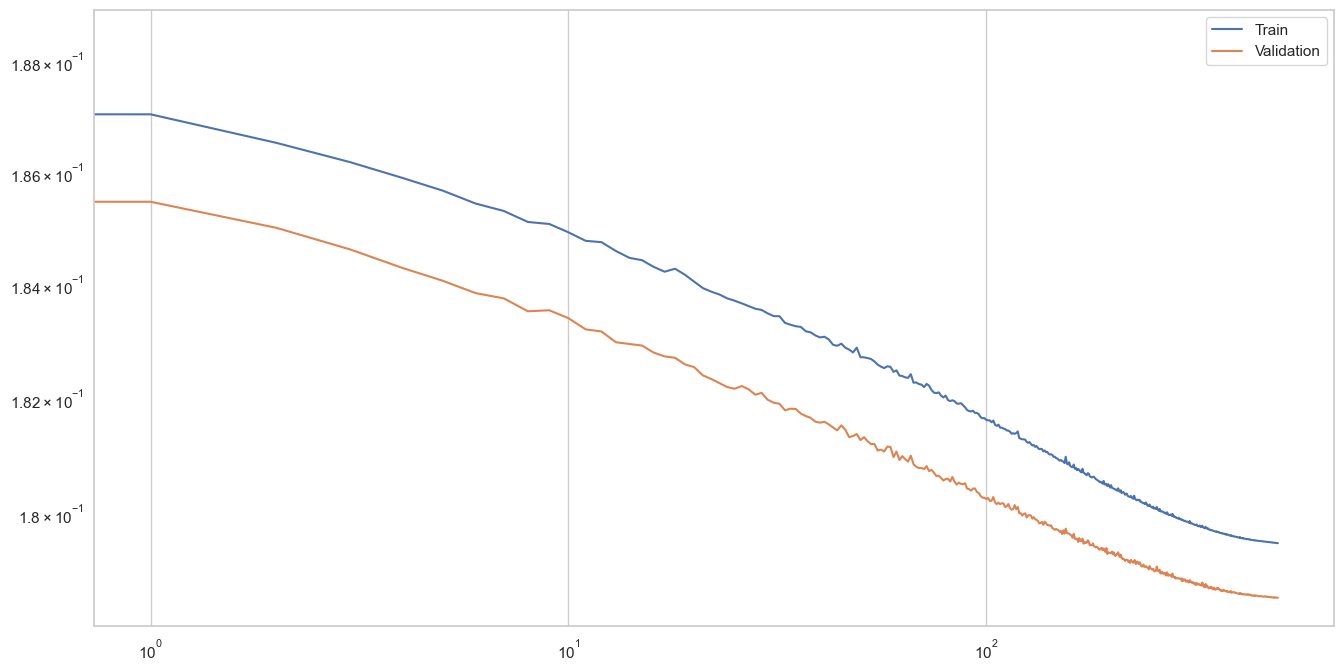

In [36]:
# plotting the loss curves
fig, axs = plt.subplots(1, figsize=(16, 8))
axs.loglog(history_train, label="Train")
axs.loglog(history_valid, label="Validation")
plt.legend()
plt.show()

In [37]:
y_pred_probs = ANN(X_test_array, params)
print('AUC Score:', roc_auc_score(y_test_array, y_pred_probs))

fpr, tpr, thresholds = roc_curve(y_test_array, y_pred_probs)

# Find threshold that gives sensitivity >= 0.7
best_thresh = None
for thresh, sens in zip(thresholds, tpr):
    if sens >= 0.70:
        best_thresh = thresh
        print(f"Threshold: {thresh:.3f}, Sensitivity: {sens:.3f}")
        break

# Apply the threshold here
y_pred = (y_pred_probs >= best_thresh).astype(int)

tn, fp, fn, tp = confusion_matrix(y_test_array, y_pred).ravel()
specificity = tn / (tn + fp)

print(f"Specificity: {specificity:.4f}")
print(f"Flagged as risky: {(tp + fp) / len(y_test_array) * 100:.1f}% of all customers")
print(f"TP: {tp}, FP: {fp}, TN: {tn}, FN: {fn}")
print(f"Total flagged: {tp + fp}")
print(f"Actual defaults in test set: {tp + fn}")

AUC Score: 0.8681820060277118
Threshold: 0.101, Sensitivity: 0.700
Specificity: 0.8634
Flagged as risky: 17.4% of all customers
TP: 1364, FP: 3756, TN: 23746, FN: 584
Total flagged: 5120
Actual defaults in test set: 1948


## Random Forest

In [40]:
#first tree-based model: Random Forest
cl_forest = RandomForestClassifier(random_state=123, max_depth=3, n_estimators=300, class_weight='balanced')
cl_forest.fit(X_train_scaled, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",3
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y_

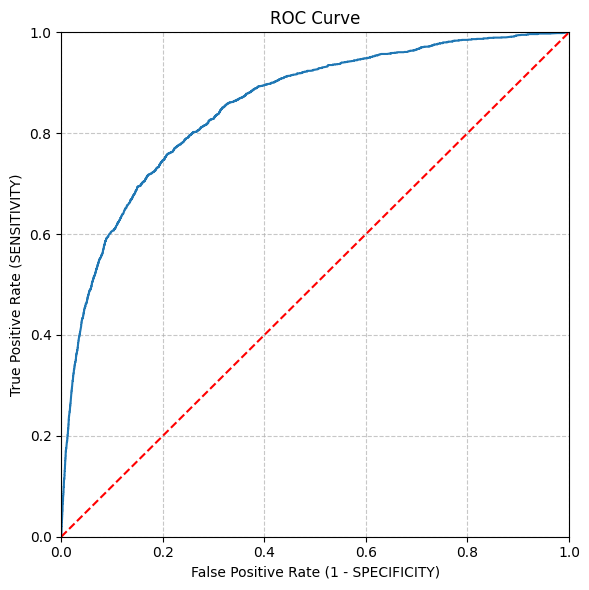

AUC Score: 0.8536068027822923
Threshold: 0.531, Sensitivity: 0.700
Specificity: 0.8417
Flagged as risky: 19.5% of all customers
TP: 1404, FP: 4432, TN: 23563, FN: 601
Total flagged: 5836
Actual defaults in test set: 2005


In [41]:
rf_prob = cl_forest.predict_proba(X_test_scaled)
clf_preds = rf_prob[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, clf_preds)
plot_roc_curve(fpr, tpr)
print('AUC Score:', roc_auc_score(y_test, clf_preds))

# Find threshold that gives sensitivity >= 0.7
best_thresh = None
for thresh, sens in zip(thresholds, tpr):
    if sens >= 0.70:
        best_thresh = thresh
        print(f"Threshold: {thresh:.3f}, Sensitivity: {sens:.3f}")
        break

# Apply threshold
y_pred = (clf_preds >= best_thresh).astype(int)

tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
specificity = tn / (tn + fp)

print(f"Specificity: {specificity:.4f}")
print(f"Flagged as risky: {(tp + fp) / len(y_test) * 100:.1f}% of all customers")
print(f"TP: {tp}, FP: {fp}, TN: {tn}, FN: {fn}")
print(f"Total flagged: {tp + fp}")
print(f"Actual defaults in test set: {tp + fn}")

## XG Boost

In [42]:
#xgboost is a gradient boosting library that is optimized for speed and performance. The following code trains an XGBoost classifier on the training data and evaluates its performance using the ROC curve and AUC score.
clf = XGBClassifier(
    random_state=123,
    n_estimators=150,
    learning_rate=0.05,
    max_depth=5,
    scale_pos_weight=(y_train == 0).sum() / (y_train == 1).sum()
)

clf.fit(X_train_scaled, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

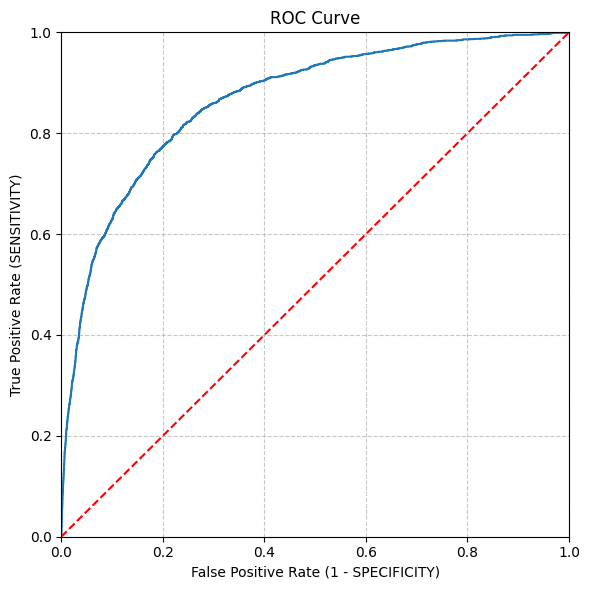

AUC Score: 0.8658043674525064
Accuracy: 79.94%
Threshold: 0.574, Sensitivity: 0.700
Specificity: 0.8558
Flagged as risky: 18.1% of all customers
TP: 1404, FP: 4036, TN: 23959, FN: 601
Total flagged: 5440
Actual defaults in test set: 2005


In [43]:
clf_scores_proba = clf.predict_proba(X_test_scaled)
clf_preds = clf_scores_proba[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, clf_preds)
plot_roc_curve(fpr, tpr)
print('AUC Score:', roc_auc_score(y_test, clf_preds))

accuracy = accuracy_score(y_test, clf.predict(X_test_scaled))
print("Accuracy: %.2f%%" % (accuracy * 100.0))

# Find threshold that gives sensitivity >= 0.7
best_thresh = None
for thresh, sens in zip(thresholds, tpr):
    if sens >= 0.70:
        best_thresh = thresh
        print(f"Threshold: {thresh:.3f}, Sensitivity: {sens:.3f}")
        break

# Apply threshold to proba scores
y_pred = (clf_preds >= best_thresh).astype(int)

tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
specificity = tn / (tn + fp)

print(f"Specificity: {specificity:.4f}")
print(f"Flagged as risky: {(tp + fp) / len(y_test) * 100:.1f}% of all customers")
print(f"TP: {tp}, FP: {fp}, TN: {tn}, FN: {fn}")
print(f"Total flagged: {tp + fp}")
print(f"Actual defaults in test set: {tp + fn}")

## CatBoost

In [44]:
#another tree based model: catboost
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train_scaled, y_train, test_size=0.2, random_state=42, stratify=y_train
)

cat_model = CatBoostClassifier(
    iterations=500,
    learning_rate=0.05,
    depth=6,
    auto_class_weights='Balanced',
    random_seed=123,
    eval_metric='AUC',
    verbose=100
)

cat_model.fit(
    X_tr, y_tr,
    eval_set=(X_val, y_val),
    early_stopping_rounds=50
)

cat_test_preds = cat_model.predict_proba(X_test_scaled)[:, 1]
print(f"CatBoost Test AUC: {roc_auc_score(y_test, cat_test_preds):.4f}")

0:	test: 0.8497800	best: 0.8497800 (0)	total: 85ms	remaining: 42.4s
100:	test: 0.8691316	best: 0.8691316 (100)	total: 1.06s	remaining: 4.19s
200:	test: 0.8705548	best: 0.8705548 (200)	total: 2.16s	remaining: 3.22s
300:	test: 0.8715195	best: 0.8716611 (271)	total: 3.26s	remaining: 2.15s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 0.8716610699
bestIteration = 271

Shrink model to first 272 iterations.
CatBoost Test AUC: 0.8668


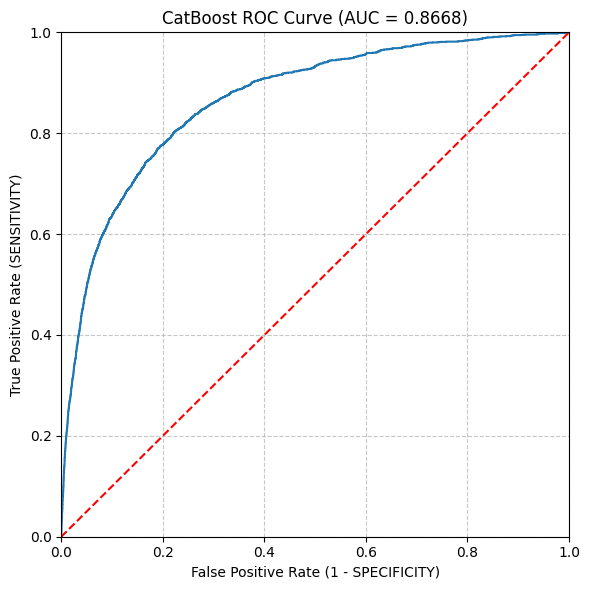

In [45]:
from sklearn.metrics import roc_curve

fpr_cat, tpr_cat, thresholds_cat = roc_curve(y_test, cat_test_preds)
plot_roc_curve(fpr_cat, tpr_cat, 
               label=f"CatBoost ROC Curve (AUC = {roc_auc_score(y_test, cat_test_preds):.4f})")

## Ensemble Methodology

In [46]:
# feature engineering
df = train_df
df['IncomePerPerson'] = df['MonthlyIncome'] / (df['NumberOfDependents'] + 1)
df['TotalLate'] = (df['NumberOfTime30-59DaysPastDueNotWorse'] +
                    df['NumberOfTime60-89DaysPastDueNotWorse'] +
                    df['NumberOfTimes90DaysLate'])
df['CreditUtilizationAge'] = df['RevolvingUtilizationOfUnsecuredLines'] / (df['age'] + 1)

X = df.drop(['SeriousDlqin2yrs', 'ID'], axis=1)
y = df['SeriousDlqin2yrs']

# impute before split to get column means, then apply to train/test separately
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=123, stratify=y
)

imputer = SimpleImputer(strategy='median')
X_train_imp = pd.DataFrame(imputer.fit_transform(X_train), columns=X.columns)
X_test_imp  = pd.DataFrame(imputer.transform(X_test),      columns=X.columns)

## LightGBM

In [ ]:
#Initializing and training LightGBM
# Hold out a validation set FROM TRAINING DATA ONLY for early stopping
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train_imp, y_train, test_size=0.2, random_state=42, stratify=y_train
)

lgb_model = lgb.LGBMClassifier(
    boosting_type='gbdt',
    objective='binary',
    metric='auc',
    learning_rate=0.05,
    n_estimators=1000,
    num_leaves=31,
    class_weight='balanced',
    random_state=123
)

lgb_model.fit(
    X_tr, y_tr,
    eval_set=[(X_val, y_val)],   # validation only, never X_test
    callbacks=[lgb.early_stopping(50), lgb.log_evaluation(100)]
)

lgb_test_preds = lgb_model.predict_proba(X_test_imp)[:, 1]
print(f"LightGBM Test AUC: {roc_auc_score(y_test, lgb_test_preds):.4f}")


[LightGBM] [Info] Number of positive: 6417, number of negative: 89583
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002866 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1501
[LightGBM] [Info] Number of data points in the train set: 96000, number of used features: 13
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000
Training until validation scores don't improve for 50 rounds
[100]	valid_0's auc: 0.869165
Early stopping, best iteration is:
[85]	valid_0's auc: 0.869317
LightGBM Test AUC: 0.8655


## Building Augmented Dataset

### LightGBM 

In [ ]:
# Out-Of-Fold predictions for meta-features using LightGBM
N_FOLDS = 5
skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=42)

oof_lgb_preds = np.zeros(len(X_train_imp))   # OOF predictions on train set
test_lgb_folds = np.zeros((len(X_test_imp), N_FOLDS))  # test preds per fold

for fold, (train_idx, val_idx) in enumerate(skf.split(X_train_imp, y_train)):
    X_f_tr = X_train_imp.iloc[train_idx]
    y_f_tr = y_train.iloc[train_idx]
    X_f_val = X_train_imp.iloc[val_idx]
    y_f_val = y_train.iloc[val_idx]

    fold_model = lgb.LGBMClassifier(
        boosting_type='gbdt', objective='binary', metric='auc',
        learning_rate=0.05, n_estimators=500,
        num_leaves=31, class_weight='balanced', random_state=123
    )
    fold_model.fit(
        X_f_tr, y_f_tr,
        eval_set=[(X_f_val, y_f_val)],
        callbacks=[lgb.early_stopping(50), lgb.log_evaluation(200)]
    )

    oof_lgb_preds[val_idx] = fold_model.predict_proba(X_f_val)[:, 1]
    test_lgb_folds[:, fold] = fold_model.predict_proba(X_test_imp)[:, 1]
    print(f"Fold {fold+1} AUC: {roc_auc_score(y_f_val, oof_lgb_preds[val_idx]):.4f}")

test_lgb_meta = test_lgb_folds.mean(axis=1)  # average across folds for test
print(f"\nOOF AUC: {roc_auc_score(y_train, oof_lgb_preds):.4f}")

# Build augmented datasets using OOF 
X_train_aug = X_train_imp.copy()
X_train_aug['lgb_meta'] = oof_lgb_preds   # OOF preds with rows that the model never saw

X_test_aug = X_test_imp.copy()
X_test_aug['lgb_meta'] = test_lgb_meta

[LightGBM] [Info] Number of positive: 6235, number of negative: 88005
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002677 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1494
[LightGBM] [Info] Number of data points in the train set: 94240, number of used features: 13
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[97]	valid_0's auc: 0.861826
Fold 1 AUC: 0.8618
[LightGBM] [Info] Number of positive: 6235, number of negative: 88005
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002407 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[Ligh

### Random Forest

In [ ]:
# Out-Of-Fold predictions for meta-features using Random Forest
from sklearn.preprocessing import StandardScaler

X_tr, X_val, y_tr, y_val = train_test_split(
    X_train_imp, y_train, test_size=0.2, random_state=42, stratify=y_train
)

# Basic RF without OOF just to check performance
rf_model = RandomForestClassifier(
    n_estimators=300, max_depth=4,
    class_weight='balanced', random_state=123, n_jobs=-1
)
rf_model.fit(X_tr, y_tr)
rf_test_preds = rf_model.predict_proba(X_test_imp)[:, 1]
print(f"RF Test AUC: {roc_auc_score(y_test, rf_test_preds):.4f}")

# OOF loop
N_FOLDS = 5
skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=42)

oof_rf_preds  = np.zeros(len(X_train_imp))
test_rf_folds = np.zeros((len(X_test_imp), N_FOLDS))

for fold, (train_idx, val_idx) in enumerate(skf.split(X_train_imp, y_train)):
    X_f_tr  = X_train_imp.iloc[train_idx]
    y_f_tr  = y_train.iloc[train_idx]
    X_f_val = X_train_imp.iloc[val_idx]
    y_f_val = y_train.iloc[val_idx]

    fold_model = RandomForestClassifier(
        n_estimators=300, max_depth=4,
        class_weight='balanced', random_state=123, n_jobs=-1
    )
    fold_model.fit(X_f_tr, y_f_tr)

    oof_rf_preds[val_idx]   = fold_model.predict_proba(X_f_val)[:, 1]
    test_rf_folds[:, fold]  = fold_model.predict_proba(X_test_imp)[:, 1]
    print(f"Fold {fold+1} AUC: {roc_auc_score(y_f_val, oof_rf_preds[val_idx]):.4f}")

test_rf_meta = test_rf_folds.mean(axis=1)
print(f"\nOOF AUC: {roc_auc_score(y_train, oof_rf_preds):.4f}")

# Augmented datasets
X_train_aug = X_train_imp.copy()
X_train_aug['rf_meta'] = oof_rf_preds

X_test_aug = X_test_imp.copy()
X_test_aug['rf_meta'] = test_rf_meta

RF Test AUC: 0.8616
Fold 1 AUC: 0.8571
Fold 2 AUC: 0.8554
Fold 3 AUC: 0.8544
Fold 4 AUC: 0.8587
Fold 5 AUC: 0.8591

OOF AUC: 0.8567


### ANN

In [ ]:
#perfroming the same steps for ANN to get OOF predictions and then add them as meta features to the datasets
from sklearn.preprocessing import StandardScaler

input_size = X_train_imp.shape[1]  # 13, not 10
layers_size = [input_size, 64, 32, 1]
params_sa = initialize_params(layers_size)

scaler_sa = StandardScaler()
X_tr_s = scaler_sa.fit_transform(X_tr)
X_val_s = scaler_sa.transform(X_val)
X_test_s = scaler_sa.transform(X_test_imp)

params_sa = initialize_params(layers_size)
n_samples_sa = X_tr_s.shape[0]

for epoch in range(num_epochs):
    lr = max(learning_rate_min, learning_rate_max * (1 - epoch / learning_rate_decay))
    perm = np.random.permutation(n_samples_sa)
    for i in range(0, n_samples_sa, batch_size):
        idx = perm[i:i + batch_size]
        grads = grad_jit(X_tr_s[idx], y_tr.values[idx], params_sa)
        params_sa = jax.tree_util.tree_map(lambda p, g: p - lr * g, params_sa, grads)

ann_test_preds = np.array(ANN(X_test_s, params_sa)).flatten()
print(f"ANN Test AUC: {roc_auc_score(y_test, ann_test_preds):.4f}")

N_FOLDS = 5
skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=42)

oof_ann_preds  = np.zeros(len(X_train_imp))
test_ann_folds = np.zeros((len(X_test_imp), N_FOLDS))

for fold, (train_idx, val_idx) in enumerate(skf.split(X_train_imp, y_train)):
    X_f_tr  = X_train_imp.iloc[train_idx].values
    y_f_tr  = y_train.iloc[train_idx].values
    X_f_val = X_train_imp.iloc[val_idx].values
    y_f_val = y_train.iloc[val_idx].values

    # Scale using only the train fold
    scaler_fold = StandardScaler()
    X_f_tr  = scaler_fold.fit_transform(X_f_tr)
    X_f_val = scaler_fold.transform(X_f_val)
    X_test_fold = scaler_fold.transform(X_test_imp.values)

    # Re-initialize params from scratch each fold
    fold_params = initialize_params(layers_size)
    n_f = X_f_tr.shape[0]

    for epoch in range(num_epochs):
        lr = max(learning_rate_min, learning_rate_max * (1 - epoch / learning_rate_decay))
        perm = np.random.permutation(n_f)
        for i in range(0, n_f, batch_size):
            idx = perm[i:i + batch_size]
            grads = grad_jit(X_f_tr[idx], y_f_tr[idx], fold_params)
            fold_params = jax.tree_util.tree_map(lambda p, g: p - lr * g, fold_params, grads)

    oof_ann_preds[val_idx]    = np.array(ANN(X_f_val, fold_params)).flatten()
    test_ann_folds[:, fold]   = np.array(ANN(X_test_fold, fold_params)).flatten()
    print(f"Fold {fold+1} AUC: {roc_auc_score(y_f_val, oof_ann_preds[val_idx]):.4f}")

test_ann_meta = test_ann_folds.mean(axis=1)
print(f"\nOOF AUC: {roc_auc_score(y_train, oof_ann_preds):.4f}")

X_train_aug = X_train_imp.copy()
X_train_aug['ann_meta'] = oof_ann_preds

X_test_aug = X_test_imp.copy()
X_test_aug['ann_meta'] = test_ann_meta

ANN Test AUC: 0.8677
Fold 1 AUC: 0.8602
Fold 2 AUC: 0.8601
Fold 3 AUC: 0.8618
Fold 4 AUC: 0.8636
Fold 5 AUC: 0.8652

OOF AUC: 0.8621


## New XGBoost

In [ ]:
#XGBoost with augmented features 
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train_aug, y_train, test_size=0.2, random_state=42, stratify=y_train
)

# Same random_state as original split — no re-splitting
xgb_model = XGBClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=5,
    scale_pos_weight=(y_train == 0).sum() / (y_train == 1).sum(),
    random_state=123,
    eval_metric='auc',
    early_stopping_rounds=50
)

xgb_model.fit(
    X_tr, y_tr,
    eval_set=[(X_val, y_val)],  # for monitoring only, not early stopping source of truth ideally
    verbose=100
)

xgb_test_preds = xgb_model.predict_proba(X_test_aug)[:, 1]
print(f"XGBoost Test AUC: {roc_auc_score(y_test, xgb_test_preds):.4f}")

[0]	validation_0-auc:0.85791
[100]	validation_0-auc:0.86147
[115]	validation_0-auc:0.86168
XGBoost Test AUC: 0.8680


## New CatBoost

In [ ]:
#CatBoost with augmented features
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train_aug, y_train, test_size=0.2, random_state=42, stratify=y_train
)

cat_model = CatBoostClassifier(
    iterations=500,
    learning_rate=0.05,
    depth=6,
    auto_class_weights='Balanced',
    random_seed=123,
    eval_metric='AUC',
    verbose=100
)

cat_model.fit(
    X_tr, y_tr,
    eval_set=(X_val, y_val),
    early_stopping_rounds=50
)

cat_test_preds = cat_model.predict_proba(X_test_aug)[:, 1]
print(f"CatBoost Test AUC: {roc_auc_score(y_test, cat_test_preds):.4f}")

0:	test: 0.8468502	best: 0.8468502 (0)	total: 15.1ms	remaining: 7.54s
100:	test: 0.8625882	best: 0.8625882 (100)	total: 1.03s	remaining: 4.06s
200:	test: 0.8627811	best: 0.8629152 (178)	total: 2.04s	remaining: 3.03s
300:	test: 0.8630672	best: 0.8631867 (263)	total: 3.07s	remaining: 2.03s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 0.8631867395
bestIteration = 263

Shrink model to first 264 iterations.
CatBoost Test AUC: 0.8690


## Weighted Ensemble

In [51]:
from scipy.optimize import minimize
from sklearn.linear_model import LogisticRegression

# OOF predictions for XGB and CAT on the training set 
# Needed so the LR meta-learner can train without leakage.
# Test predictions are reused directly from the cells above.

N_FOLDS = 5
skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=42)

oof_xgb_aug = np.zeros(len(X_train_aug))
oof_cat_aug = np.zeros(len(X_train_aug))

for fold, (train_idx, val_idx) in enumerate(skf.split(X_train_aug, y_train)):
    X_f_tr,  X_f_val = X_train_aug.iloc[train_idx], X_train_aug.iloc[val_idx]
    y_f_tr,  y_f_val = y_train.iloc[train_idx],     y_train.iloc[val_idx]

    xgb_fold = XGBClassifier(
        n_estimators=500, learning_rate=0.05, max_depth=5,
        scale_pos_weight=(y_f_tr == 0).sum() / (y_f_tr == 1).sum(),
        random_state=123, eval_metric='auc', early_stopping_rounds=50,
        verbosity=0
    )
    xgb_fold.fit(X_f_tr, y_f_tr, eval_set=[(X_f_val, y_f_val)], verbose=False)
    oof_xgb_aug[val_idx] = xgb_fold.predict_proba(X_f_val)[:, 1]

    cat_fold = CatBoostClassifier(
        iterations=500, learning_rate=0.05, depth=6,
        auto_class_weights='Balanced', random_seed=123,
        eval_metric='AUC', verbose=0
    )
    cat_fold.fit(X_f_tr, y_f_tr, eval_set=(X_f_val, y_f_val),
                 early_stopping_rounds=50)
    oof_cat_aug[val_idx] = cat_fold.predict_proba(X_f_val)[:, 1]

    print(f"Fold {fold+1} — XGB AUC: {roc_auc_score(y_f_val, oof_xgb_aug[val_idx]):.4f} | "
          f"CAT AUC: {roc_auc_score(y_f_val, oof_cat_aug[val_idx]):.4f}")

print(f"\nXGB-aug OOF AUC: {roc_auc_score(y_train, oof_xgb_aug):.4f}")
print(f"CAT-aug OOF AUC: {roc_auc_score(y_train, oof_cat_aug):.4f}")

# Building the stack for blending and meta-learning:
# RF is excluded — its LR coefficient was negative in earlier experiments,
# meaning it hurts the ensemble once the stronger models are present.
# test predictions for XGB and CAT are reused from the cells above.

MODEL_NAMES = ['LGB', 'ANN', 'XGB-aug', 'CAT-aug']

oof_stack  = np.column_stack([oof_lgb_preds, oof_ann_preds,
                               oof_xgb_aug,  oof_cat_aug])
test_stack = np.column_stack([test_lgb_meta, test_ann_meta,
                               xgb_test_preds, cat_test_preds])

print("\nIndividual OOF AUCs:")
for name, col in zip(MODEL_NAMES, oof_stack.T):
    print(f"  {name}: {roc_auc_score(y_train, col):.4f}")

#  Nelder-Mead optimized blending to maximize OOF AUC
def neg_auc_oof(raw_weights):
    w = np.abs(raw_weights)
    w = w / w.sum()
    return -roc_auc_score(y_train, oof_stack @ w)

result = minimize(
    neg_auc_oof,
    x0=np.ones(4) / 4,
    method='Nelder-Mead',
    options={'maxiter': 50000, 'xatol': 1e-8, 'fatol': 1e-8}
)
opt_w = np.abs(result.x) / np.abs(result.x).sum()
opt_preds = test_stack @ opt_w

print("\n=== Nelder-Mead Optimized Blend ===")
for name, w in zip(MODEL_NAMES, opt_w):
    print(f"  {name}: {w:.4f}")
print(f"  OOF AUC:  {roc_auc_score(y_train, oof_stack @ opt_w):.4f}")
print(f"  Test AUC: {roc_auc_score(y_test, opt_preds):.4f}")

# Logistic Regression meta-learner
meta_lr = LogisticRegression(C=1.0, random_state=123, max_iter=1000)
meta_lr.fit(oof_stack, y_train)
lr_preds = meta_lr.predict_proba(test_stack)[:, 1]

print("\n=== Logistic Regression Meta-Learner ===")
for name, coef in zip(MODEL_NAMES, meta_lr.coef_[0]):
    print(f"  {name}: {coef:.4f}")
print(f"  OOF AUC:  {roc_auc_score(y_train, meta_lr.predict_proba(oof_stack)[:, 1]):.4f}")
print(f"  Test AUC: {roc_auc_score(y_test, lr_preds):.4f}")

Fold 1 — XGB AUC: 0.8617 | CAT AUC: 0.8618
Fold 2 — XGB AUC: 0.8594 | CAT AUC: 0.8612
Fold 3 — XGB AUC: 0.8607 | CAT AUC: 0.8617
Fold 4 — XGB AUC: 0.8637 | CAT AUC: 0.8657
Fold 5 — XGB AUC: 0.8656 | CAT AUC: 0.8655

XGB-aug OOF AUC: 0.8611
CAT-aug OOF AUC: 0.8630

Individual OOF AUCs:
  LGB: 0.8629
  ANN: 0.8621
  XGB-aug: 0.8611
  CAT-aug: 0.8630

=== Nelder-Mead Optimized Blend ===
  LGB: 0.4314
  ANN: 0.1026
  XGB-aug: 0.1482
  CAT-aug: 0.3178
  OOF AUC:  0.8639
  Test AUC: 0.8689

=== Logistic Regression Meta-Learner ===
  LGB: 1.9020
  ANN: 2.1229
  XGB-aug: 0.8840
  CAT-aug: 1.5057
  OOF AUC:  0.8638
  Test AUC: 0.8689


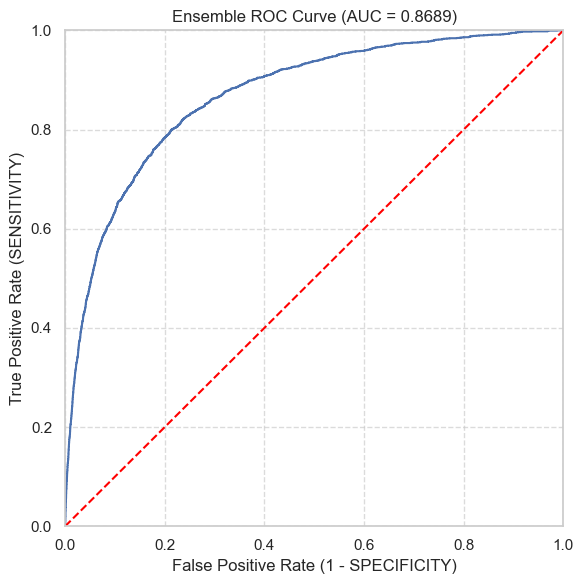

In [52]:
from sklearn.metrics import roc_curve

fpr, tpr, _ = roc_curve(y_test, opt_preds)
plot_roc_curve(fpr, tpr, label=f"Ensemble ROC Curve (AUC = {roc_auc_score(y_test, opt_preds):.4f})")

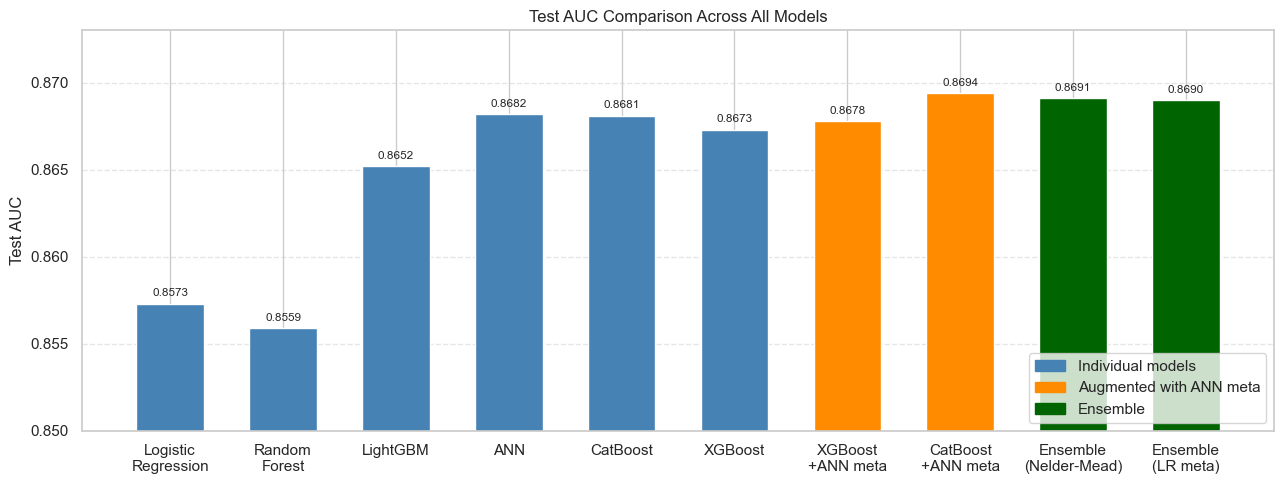

In [ ]:
#plotting the AUCs of all models for comparison
models = [
    'Logistic\nRegression', 'Random\nForest', 'LightGBM',
    'ANN', 'CatBoost', 'XGBoost',
    'XGBoost\n+ANN meta', 'CatBoost\n+ANN meta',
    'Ensemble\n(Nelder-Mead)', 'Ensemble\n(LR meta)'
]
aucs = [0.8573, 0.8559, 0.8652, 0.8682, 0.8681, 0.8673,
        0.8678, 0.8694, 0.8691, 0.8690]
colors = (['steelblue'] * 6 +      # individual models
          ['darkorange'] * 2 +      # augmented models
          ['darkgreen'] * 2)        # ensembles

fig, ax = plt.subplots(figsize=(13, 5))
bars = ax.bar(models, aucs, color=colors, edgecolor='white', width=0.6)

# Annotate each bar with its AUC value
for bar, auc in zip(bars, aucs):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.0003,
            f'{auc:.4f}', ha='center', va='bottom', fontsize=8.5)

ax.set_ylim(0.850, 0.873)
ax.set_ylabel('Test AUC')
ax.set_title('Test AUC Comparison Across All Models')
ax.grid(True, linestyle='--', alpha=0.5, axis='y')
ax.yaxis.set_major_formatter(plt.FormatStrFormatter('%.3f'))

# Legend
from matplotlib.patches import Patch
legend_elements = [Patch(color='steelblue',   label='Individual models'),
                   Patch(color='darkorange',   label='Augmented with ANN meta'),
                   Patch(color='darkgreen',    label='Ensemble')]
ax.legend(handles=legend_elements, loc='lower right')

plt.tight_layout()
plt.show()